### 1. Import Data and Required Packages

* Importing NumPy, Pandas, OpenCV, TensorFlow, Matplotlib, Seaborn and Warnings Library.

In [1]:
import numpy as np
import pandas as pd
import cv2
import os

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D

import warnings
warnings.filterwarnings("ignore")

### 2. Dataset Load

In [7]:
import os

train_path = r"D:\Projects\Facial Emotion Recognition\notebook\data\train"
test_path  = r"D:\Projects\Facial Emotion Recognition\notebook\data\test"

In [8]:
print(train_path)

D:\Projects\Facial Emotion Recognition\notebook\data\train


In [9]:
print(test_path)

D:\Projects\Facial Emotion Recognition\notebook\data\test


#### Check Number of Images in Each Class

In [10]:
print(os.path.exists(train_path))

True


In [11]:
import os

print(os.getcwd())

d:\Projects\Facial Emotion Recognition\notebook\data


##### image count code

In [12]:
import os

train_path = r"D:\Projects\Facial Emotion Recognition\notebook\data\train"

for emotion in os.listdir(train_path):
    emotion_folder = os.path.join(train_path, emotion)

    if os.path.isdir(emotion_folder):
        count = len(os.listdir(emotion_folder))
        print(f"{emotion}: {count}")

angry: 3995
disgust: 436
fear: 4097
happy: 7215
neutral: 4965
sad: 4830
surprise: 3171


### Image Genrator

In [16]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [17]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical'
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


# Create DataFrame

In [19]:
import os
import pandas as pd

data = []

train_path = r"D:\Projects\Facial Emotion Recognition\notebook\data\train"  # path

for emotion in os.listdir(train_path):

    emotion_path = os.path.join(train_path, emotion)

    for image in os.listdir(emotion_path):

        image_path = os.path.join(emotion_path, image)

        data.append({
            "image_path": image_path,
            "emotion": emotion
        })

df = pd.DataFrame(data)

df.head()

,image_path,emotion
0,D:\Projects\Facial Emotion Recognition\noteboo...,angry
1,D:\Projects\Facial Emotion Recognition\noteboo...,angry
2,D:\Projects\Facial Emotion Recognition\noteboo...,angry
3,D:\Projects\Facial Emotion Recognition\noteboo...,angry
4,D:\Projects\Facial Emotion Recognition\noteboo...,angry


#### Shape of the dataset

In [20]:
df.shape

(28709, 2)

#### Data Info

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28709 entries, 0 to 28708
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  28709 non-null  object
 1   emotion     28709 non-null  object
dtypes: object(2)
memory usage: 448.7+ KB


#### Emotion Value_counts

In [22]:
df['emotion'].value_counts()

emotion
happy       7215
neutral     4965
sad         4830
fear        4097
angry       3995
surprise    3171
disgust      436
Name: count, dtype: int64

1. Bar Plot:

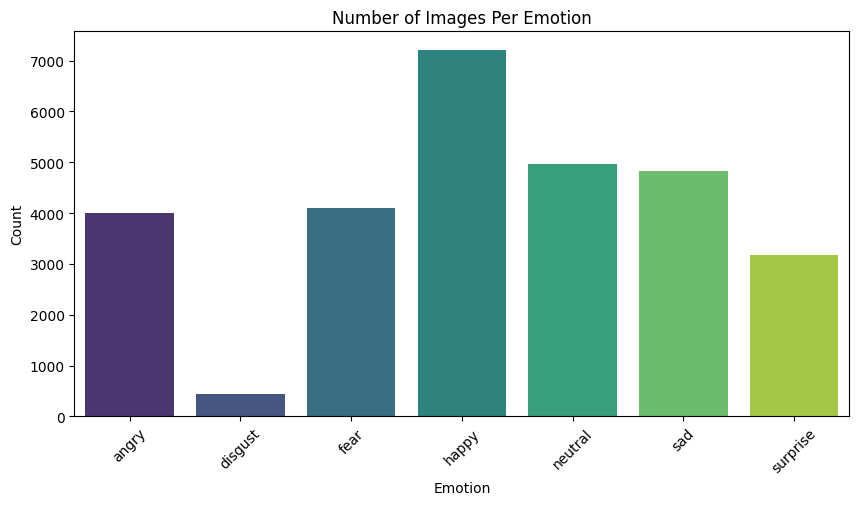

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.barplot(
    x=df["Emotion"],
    y=df["Count"],
    palette="viridis"
)

plt.title("Number of Images Per Emotion")
plt.xticks(rotation=45)

plt.show()

2. Random sample image visualization:

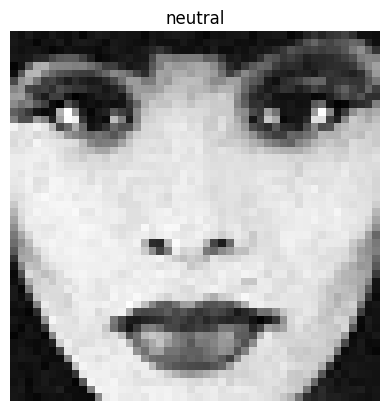

In [15]:
import random
import cv2
import matplotlib.pyplot as plt

emotion = random.choice(os.listdir("train"))

img_path = os.path.join(
    train_path,
    emotion,
    random.choice(os.listdir(os.path.join(train_path, emotion)))
)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap="gray")
plt.title(emotion)
plt.axis("off")
plt.show()

3. Image Size Check

In [24]:
import cv2
import random

sample_path = df['image_path'].sample(1).iloc[0]

img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

print("Shape:", img.shape)

Shape: (48, 48)


4. Random 9 Images Visualization

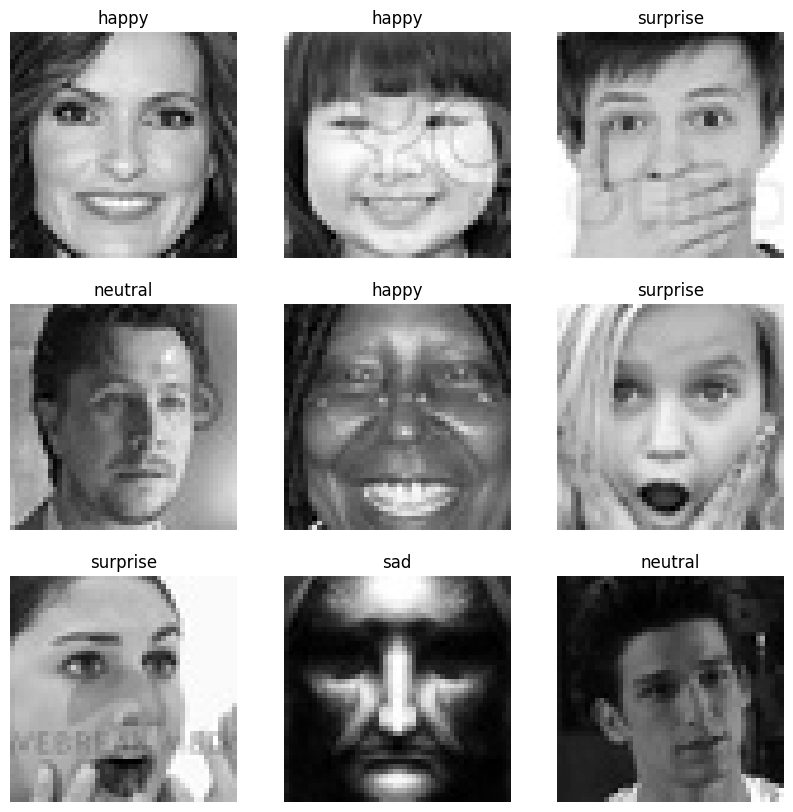

In [25]:
import matplotlib.pyplot as plt
import cv2

plt.figure(figsize=(10,10))

for i in range(9):

    sample = df.sample(1)

    img_path = sample['image_path'].iloc[0]
    emotion = sample['emotion'].iloc[0]

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(emotion)
    plt.axis('off')

plt.show()

#### Missing Values Check

In [26]:
df.isnull().sum()

image_path    0
emotion       0
dtype: int64

5. Emotion Distribution Pie Chart

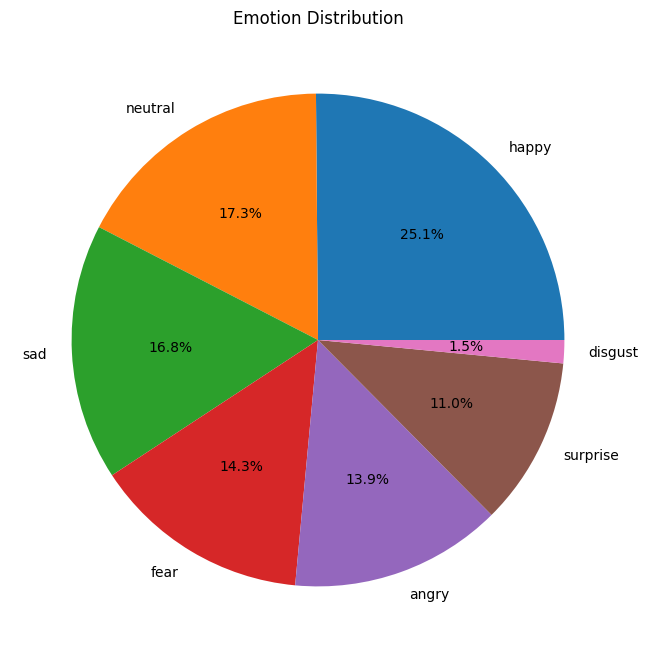

In [27]:
import matplotlib.pyplot as plt

emotion_counts = df['emotion'].value_counts()

plt.figure(figsize=(8,8))

plt.pie(
    emotion_counts,
    labels=emotion_counts.index,
    autopct='%1.1f%%'
)

plt.title("Emotion Distribution")
plt.show()

6. Random Images Grid

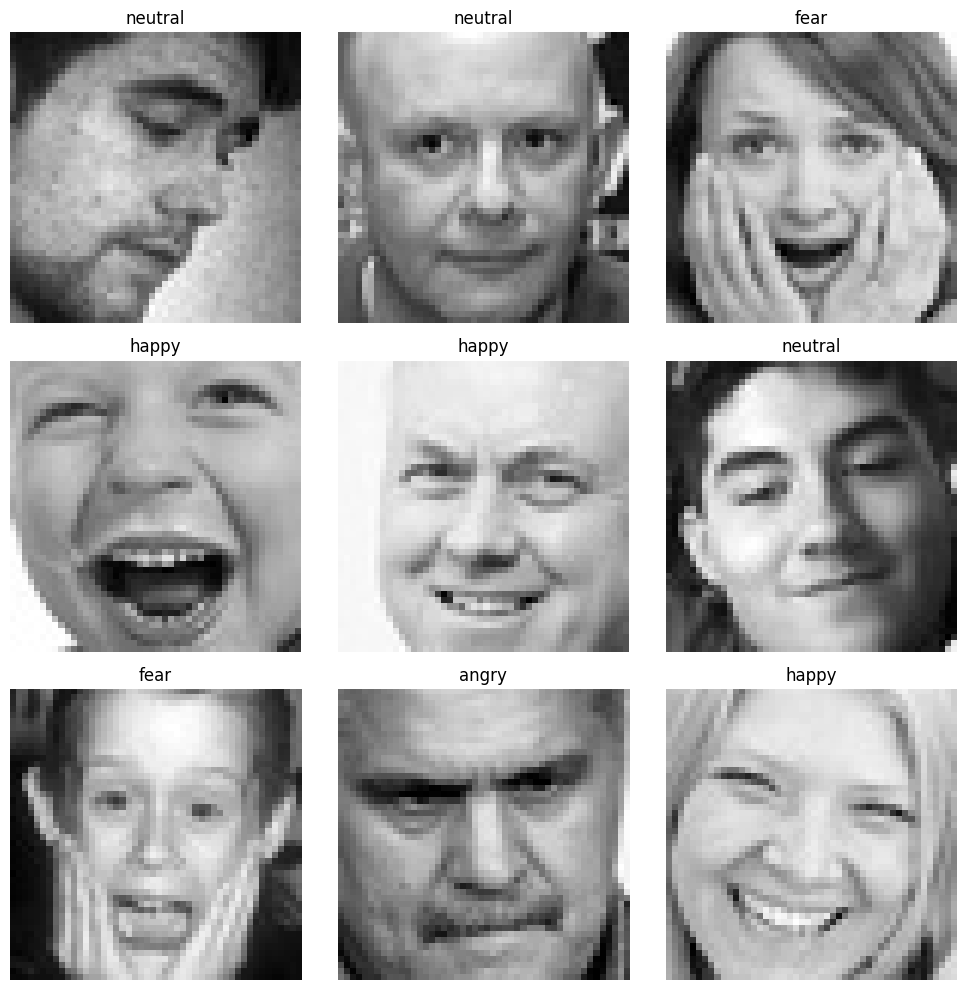

In [28]:
import random
import cv2
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for i in range(9):

    sample = df.sample(1)

    img_path = sample['image_path'].iloc[0]
    emotion = sample['emotion'].iloc[0]

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap='gray')
    plt.title(emotion)
    plt.axis('off')

plt.tight_layout()
plt.show()

7. Image Shape Check

In [29]:
import cv2

sample_path = df['image_path'].iloc[0]

img = cv2.imread(
    sample_path,
    cv2.IMREAD_GRAYSCALE
)

print(img.shape)

(48, 48)
